# Tree Model Interpretation using SHAP

[![open in colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ing-bank/probatus/blob/master/docs/tutorials/nb_shap_model_interpreter.ipynb)

There are various techniques for explaining machine learning models, each with its own strengths and limitations. [SHAP](https://shap.readthedocs.io/en/latest/) (SHapley Additive exPlanations) is a game-theoretic approach that effectively interprets model outputs and is particularly useful for exploring feature importance.

### Pros:
- **Strong theoretical foundation** for model explanations.
- **Versatile and user-friendly**, supporting both local (single-sample) and global (dataset-wide) explanations with intuitive visualizations.
- **Considers feature interactions**, unlike some simpler importance metrics.
- **Efficient computation**, particularly for tree-based models.

### Cons:
- **Documentation gaps**, making it harder to troubleshoot and apply in complex cases.
- **Slower performance** for certain explainers, such as `KernelExplainer`.

### Model Analysis

Now, let’s assume we want to analyze the following model:

In [1]:
%%capture
!pip install probatus

In [2]:
import warnings

import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from probatus.model import ShapModelInterpreter

warnings.filterwarnings("ignore")

feature_names = ["f1", "f2", "f3", "f4"]

# Prepare two samples
X, y = make_classification(n_samples=1000, n_features=4, random_state=0)
X = pd.DataFrame(X, columns=feature_names)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Prepare and fit model. Remember about class_weight="balanced" or an equivalent.
model = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=0)
model = model.fit(X_train, y_train)

## ShapModelInterpreter  

The `ShapModelInterpreter` class in Probatus provides a convenient way to interpret machine learning models. It currently supports **tree-based and linear models**.  

### Feature Importance  

We first compute a report detailing various properties of the model:  

- **`mean_abs_shap_value_test`** – SHAP feature importance on the test set, offering an **unbiased** measure of a feature’s impact on unseen data.  
- **`mean_abs_shap_value_train`** – SHAP feature importance on the train set. Since the model is trained on this data, it may be **biased**. A large discrepancy between train and test values could indicate **data distribution shifts, target shifts, or overfitting**.  
- **`mean_shap_value_test`** – Measures how much a feature influences predictions in the test set.  
  - **Positive values** indicate an increase in the probability of the positive class.  
  - **Negative values** indicate a decrease.  
  - In a **balanced dataset**, this value is typically near **0**.  
  - In an **imbalanced dataset**, its value depends on the majority class.  
  - Comparing this with `mean_shap_value_train` can help detect **shifts in data or target distribution**.  
- **`mean_shap_value_train`** – Similar to `mean_shap_value_test`, but computed on the training set. Discrepancies between the two may indicate potential **overfitting or dataset shifts**.

In [3]:
shap_interpreter = ShapModelInterpreter(model)
feature_importance = shap_interpreter.fit_compute(X_train, X_test, y_train, y_test)
feature_importance

,mean_abs_shap_value_test,mean_abs_shap_value_train,mean_shap_value_test,mean_shap_value_train
f1,0.312110,0.315360,-0.039777,0.048119
f4,0.084541,0.091374,-0.012685,0.011835
f3,0.051129,0.043127,0.000880,-0.000101
f2,0.006232,0.006679,-0.000339,0.000167


Run the following command to plot the SHAP feature importance.

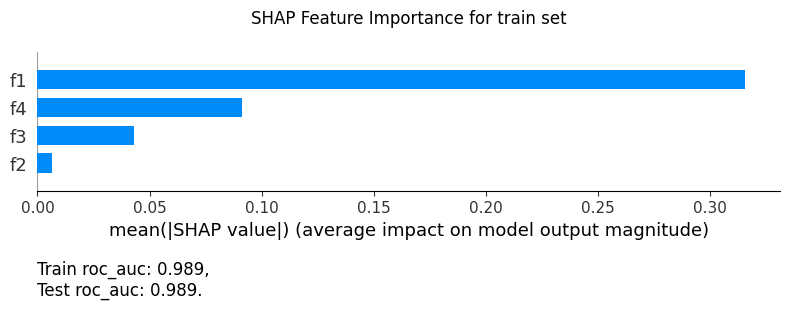

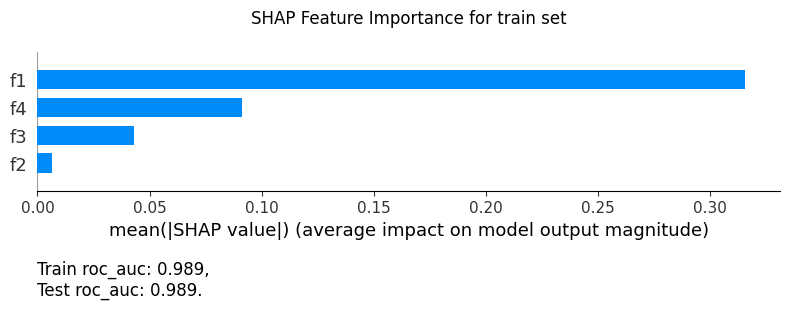

In [4]:
shap_interpreter.plot("importance", target_set="train")

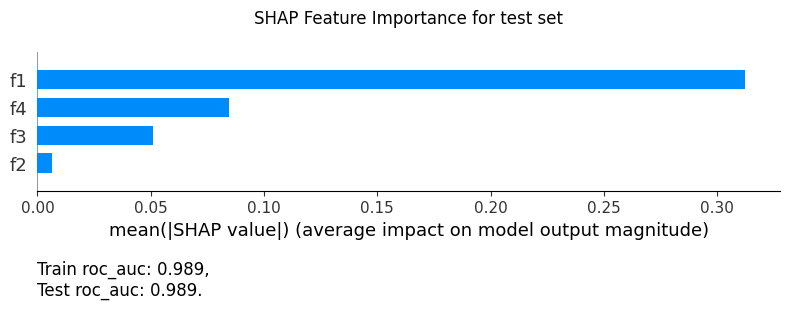

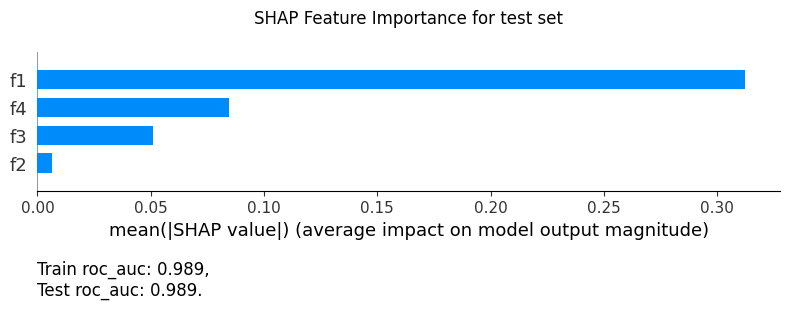

In [5]:
shap_interpreter.plot("importance", target_set="test")

The **AUC on train and test sets** is displayed in each plot to help assess potential overfitting.  

- If the **Test AUC is significantly lower than Train AUC**, this suggests that the model may be **overfitting**.  
- In such cases, the interpretation of SHAP values could be **misleading**, as the model may have learned patterns that do not generalize well to unseen data.  

To address this, we recommend **retraining the model with stronger regularization**, such as:  
- Increasing the **penalty strength** (e.g., L1/L2 regularization for linear models).  
- Reducing the **model complexity** (e.g., pruning trees or limiting tree depth).  
- Increasing the **amount of training data** or using **data augmentation**.

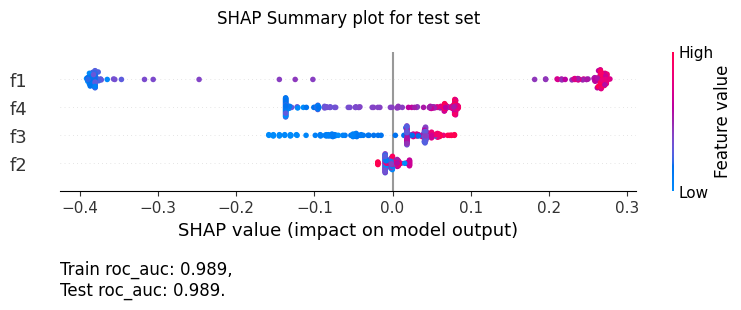

In [6]:
ax = shap_interpreter.plot("summary")

### Dependence Plot

This plot allows you to understand how the model reacts for different feature values. You can plot it for each feature in your model, or at least the top 10 features. This can provide you with further insights on how the model uses each of the features. Moreover, one can detect anomalies, as well as the effect of the outliers on the model. 

As an addition, the bottom plot presents the feature distribution histogram, and the target rate for different buckets within that feature values. This allows you to further analyse how the feature correlates with the target variable.

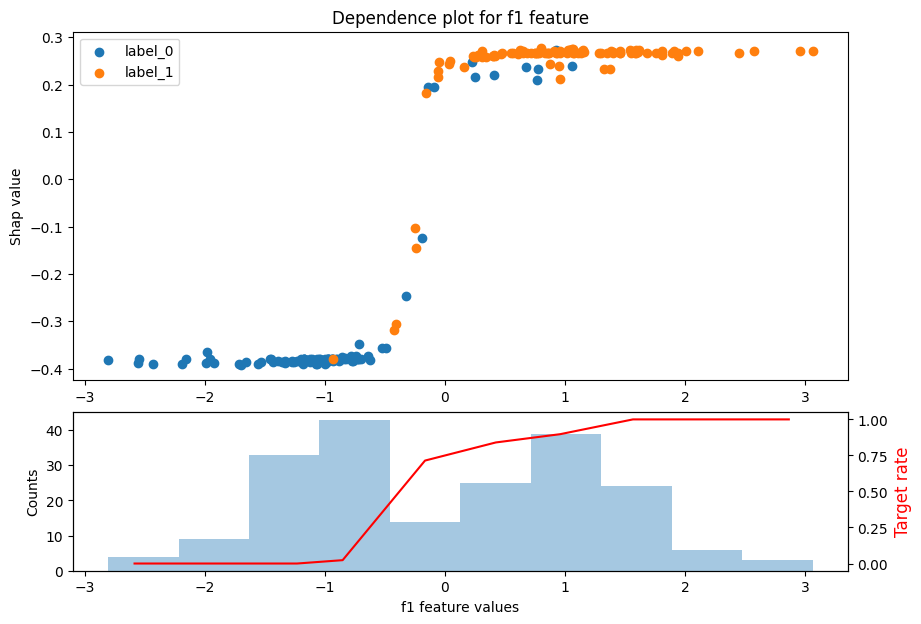

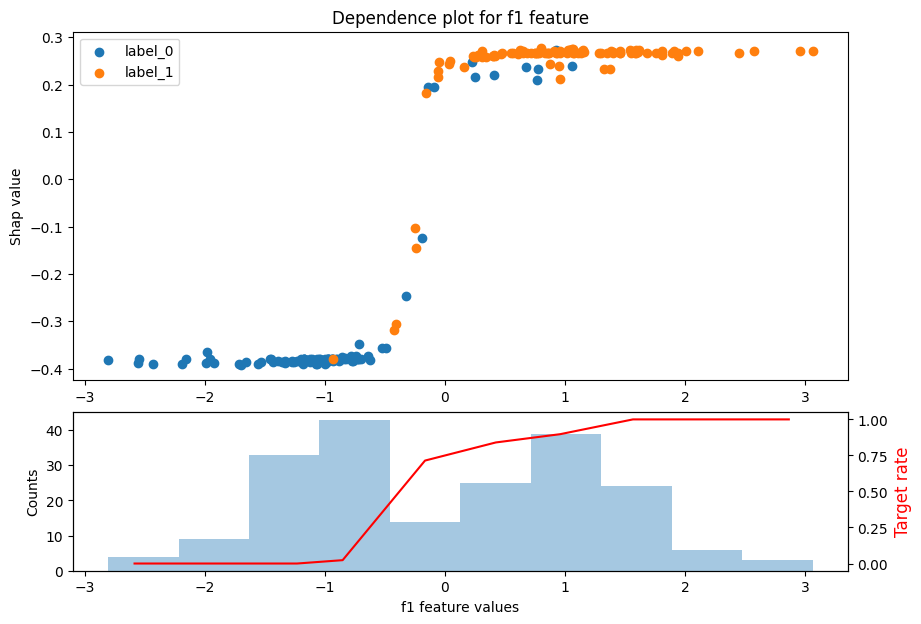

In [7]:
shap_interpreter.plot("dependence", target_columns=["f1"])

### Sample explanation

In order to explain predictions for specific samples from your test set, you can use a sample plot. For a given sample, the plot presents the force and direction of the prediction shift that each feature value causes.

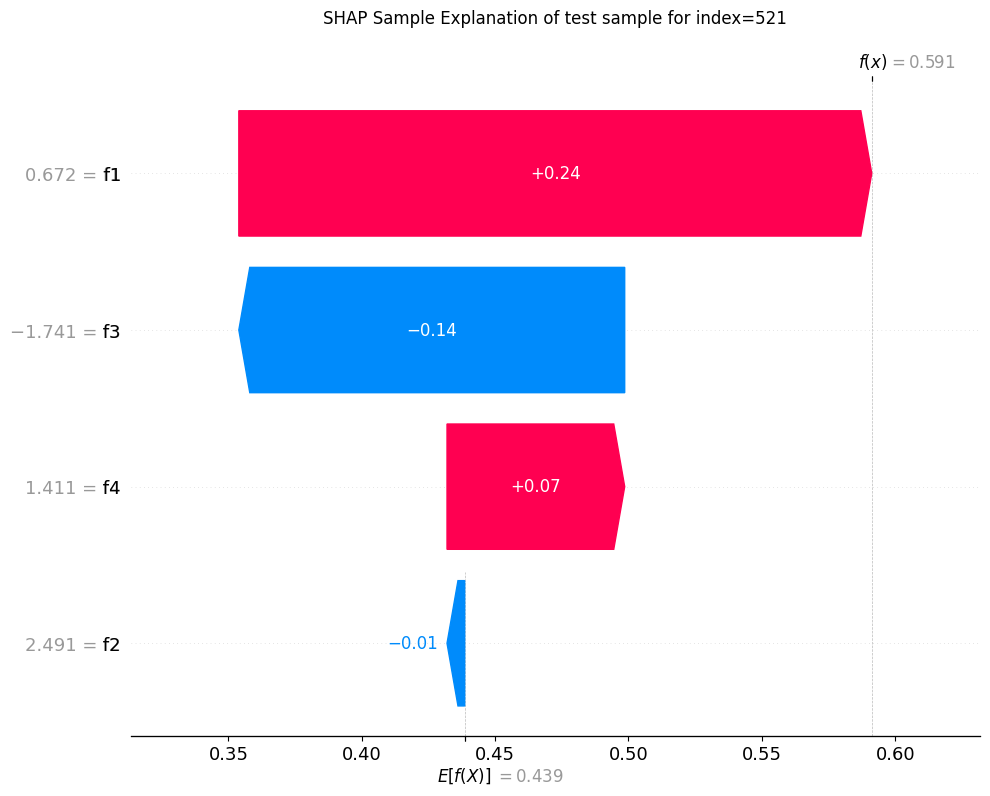

In [8]:
plots = shap_interpreter.plot("sample", samples_index=[521, 78])
plots[0]

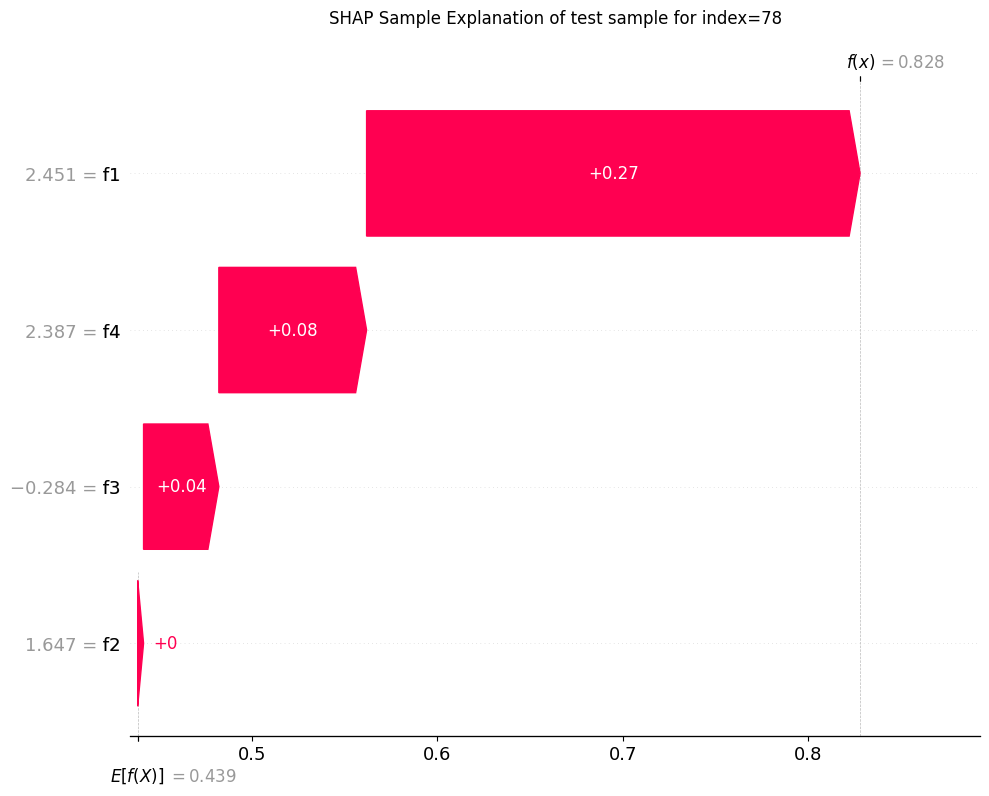

In [9]:
plots[1]

## Detecting Data or Target Distribution Shift

Let's assume that there is a shift between the train and test data:

In [10]:
X_test["f1"] = X_test["f1"] - 5
X_test["f4"] = X_test["f4"] + 5

Now, we can look into how it affects the resutls:

In [11]:
shap_interpreter = ShapModelInterpreter(model)
feature_importance = shap_interpreter.fit_compute(X_train, X_test, y_train, y_test, approximate=False)
feature_importance

,mean_abs_shap_value_test,mean_abs_shap_value_train,mean_shap_value_test,mean_shap_value_train
f3,0.055939,0.046358,0.005582,0.002801
f2,0.009365,0.006533,-0.000129,0.000185
f1,0.000000,0.313808,0.000000,-0.009209
f4,0.000000,0.089885,0.000000,-0.004479


### Visualizing SHAP Summary Plots  

In the case of features **f1** and **f4**, a shift is observed between the train and test sets. This is indicated by differences in **mean absolute SHAP values** and **mean SHAP values**, suggesting a potential change in feature importance or distribution between the two datasets.

We can visualize the **SHAP summary plots** for both the train and test sets to better understand these shifts.

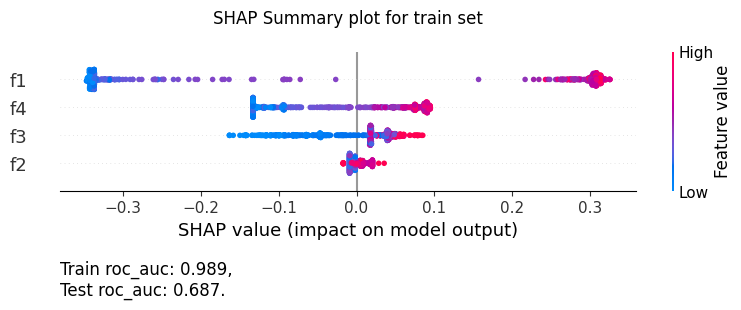

In [12]:
shap_interpreter.plot("summary", target_set="train")

This plot shows the SHAP values for each feature in the **training set**. The **color gradient** represents feature values, with **blue** indicating lower values and **red** indicating higher values. The spread of SHAP values demonstrates the impact of each feature on model predictions.

- The **Train AUC is 0.989**, suggesting that the model performs exceptionally well on training data.
- Features **f1 and f4** show strong influence in the train set, but we need to check if this pattern holds in the test set.

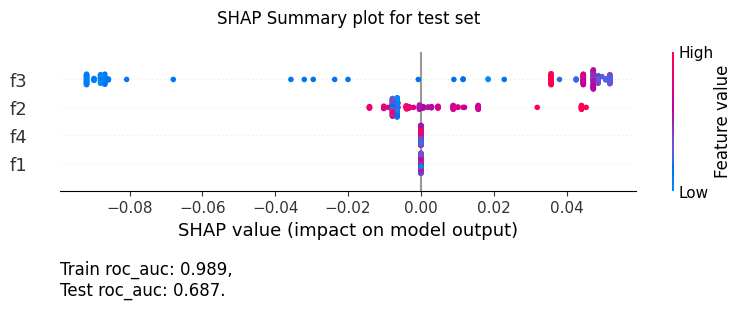

In [13]:
shap_interpreter.plot("summary", target_set="test")

This plot shows the SHAP values for the **test set**, allowing for a direct comparison with the training set.

- The **Test AUC is 0.687**, significantly lower than the Train AUC. This suggests potential **overfitting** or **data distribution shift**.
- The **importance of features f1 and f4 decreases** in the test set, indicating that their predictive power differs between the two datasets.
- The overall distribution of SHAP values has changed, reinforcing the need to investigate possible **dataset shifts** or **overfitting issues**.

### Key Takeaways  

- A significant drop in **Test AUC** compared to Train AUC suggests **overfitting**.
- Changes in **feature importance rankings and SHAP value distributions** (e.g., f1 and f4) may indicate **data distribution shifts**.
- If such discrepancies occur, retraining the model with **stronger regularization**, **better feature selection**, or **data preprocessing adjustments** may improve generalization.

## Tips for Using the Interpreter  

Before using the `ShapModelInterpreter`, consider the following best practices:  

- **Avoid underfitting or overfitting:**  
  - **Underfitting** may only reveal the most dominant relationships, hiding subtle but meaningful patterns.  
  - **Overfitting** can lead to misleading explanations by capturing relationships that do not generalize to unseen data.  

- **Perform feature selection before training the final model:**  
  - Reducing the number of features improves interpretability.  
  - Removing **highly correlated features** prevents them from distorting the SHAP explanations.  

- **Handle missing values appropriately:**  
  - Use a model that **natively supports NaNs** (e.g., **LightGBM**), or impute missing values before analysis.  
  - When imputing, consider extracting a **MissingIndicator** to assess whether missing values carry predictive meaning.  

- **Properly encode categorical features:**  
  - Use models that **support categorical variables natively** (e.g., **LightGBM**).  
  - If using One-hot encoding, note that categorical feature importance may be **spread across multiple encoded features**, making interpretation more complex.